# 03_用户分层

## 目标
- 基于客户、订单、支付数据进行用户分层，识别高价值和潜在流失用户。

## 输入
- olist_customers_dataset.csv、olist_orders_dataset.csv、olist_order_items_dataset.csv、olist_order_payments_dataset.csv

## 输出
- 用户分层标签、分层画像和分层结果表。


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/df_master.csv", 
                 parse_dates=['order_purchase_timestamp'])

In [4]:
# 只保留已完成订单
df = df[df['order_status']=='delivered'].copy()
print("已完成订单数：", len(df))
df.head(3)

已完成订单数： 110182


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,total_payment,payment_installments,product_category_name,product_category_name_english,review_score,purchase_year,purchase_month,purchase_hour,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,38.71,1.0,utilidades_domesticas,housewares,4.0,2017,10,10,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,22.76,141.46,1.0,perfumaria,perfumery,4.0,2018,7,20,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,179.12,3.0,automotivo,auto,5.0,2018,8,8,9.0


## 步骤1：计算RFM指标


In [6]:
# 以数据集最后一天+1作为参考日期
reference_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('total_payment', 'sum')
).reset_index()

print("RFM基础统计：")
print(rfm[['Recency','Frequency','Monetary']].describe())

RFM基础统计：
            Recency     Frequency       Monetary
count  93345.000000  93345.000000   93345.000000
mean     237.896599      1.033414     211.838650
std      152.554001      0.209088     642.206377
min        1.000000      1.000000       0.000000
25%      114.000000      1.000000      63.760000
50%      219.000000      1.000000     112.960000
75%      346.000000      1.000000     201.740000
max      714.000000     15.000000  109312.640000


## 步骤2：RFM打分


In [7]:
# 按分位数打分（1-5分）
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print("RFM得分分布：")
print(rfm['RFM_score'].describe())

RFM得分分布：
count    93345.000000
mean         9.003471
std          2.496249
min          3.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         15.000000
Name: RFM_score, dtype: float64


## 步骤3：用户分层


In [8]:
def segment_user(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return '高价值用户'
    elif r >= 4 and f >= 3:
        return '潜力用户'
    elif r <= 2 and f >= 3:
        return '流失高频用户'
    elif r <= 2 and m >= 4:
        return '流失高价值用户'
    elif r >= 4 and f <= 2:
        return '新客户'
    else:
        return '普通用户'

rfm['用户分层'] = rfm.apply(segment_user, axis=1)

segment_counts = rfm['用户分层'].value_counts()
print("各层用户数量：")
print(segment_counts)
print(f"\n总用户数：{len(rfm)}")

各层用户数量：
用户分层
普通用户       27933
流失高频用户     22219
潜力用户       15989
新客户        14984
高价值用户       6460
流失高价值用户     5760
Name: count, dtype: int64

总用户数：93345


## 步骤4：可视化用户分层


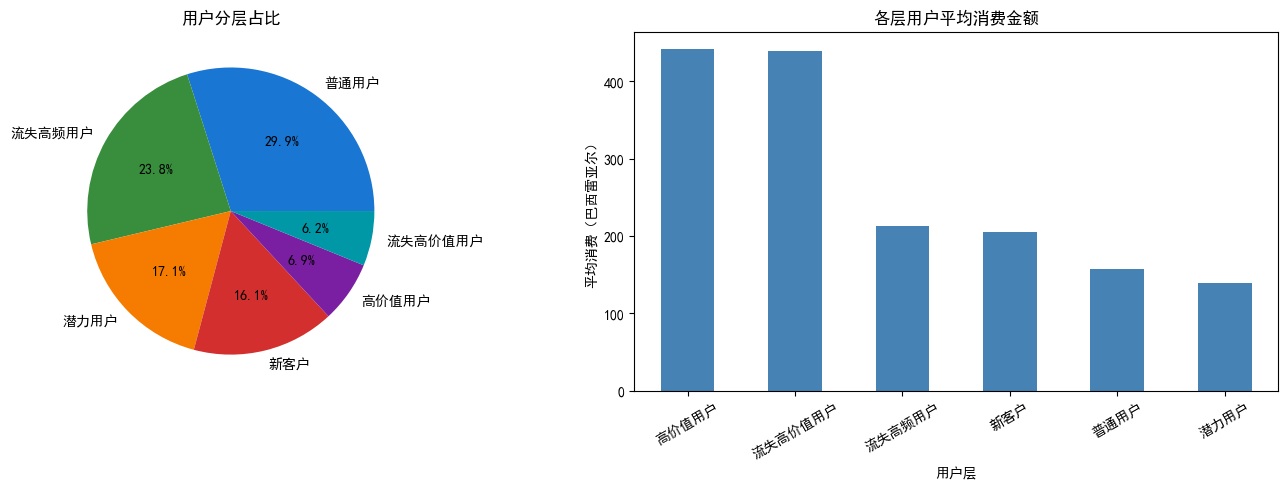

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 饼图
segment_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', 
                    colors=['#1976d2','#388e3c','#f57c00','#d32f2f','#7b1fa2','#0097a7'])
axes[0].set_title('用户分层占比')
axes[0].set_ylabel('')

# 各层平均消费
segment_monetary = rfm.groupby('用户分层')['Monetary'].mean().sort_values(ascending=False)
segment_monetary.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('各层用户平均消费金额')
axes[1].set_xlabel('用户层')
axes[1].set_ylabel('平均消费（巴西雷亚尔）')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## RFM散点图

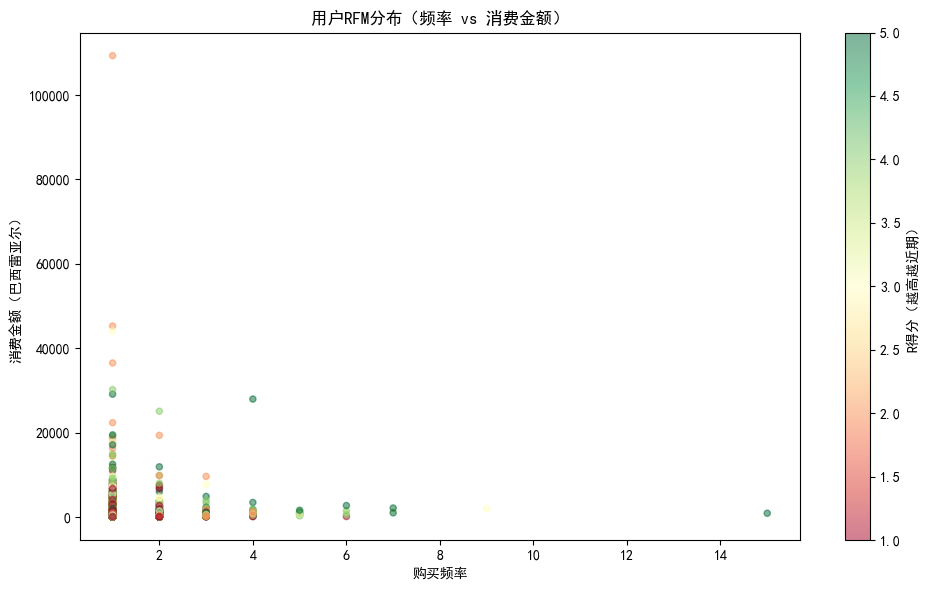

In [10]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rfm['Frequency'], rfm['Monetary'], 
                      c=rfm['R_score'], cmap='RdYlGn',
                      alpha=0.5, s=20)
plt.colorbar(scatter, label='R得分（越高越近期）')
plt.title('用户RFM分布（频率 vs 消费金额）')
plt.xlabel('购买频率')
plt.ylabel('消费金额（巴西雷亚尔）')
plt.tight_layout()
plt.show()

## 核心结论

## RFM用户分层核心发现

1. **用户以单次购买为主**：Frequency均值接近1，复购率极低，典型电商冷启动特征
2. **高价值用户占比约X%**：消费金额远高于普通用户，是重点维护对象
3. **流失风险用户不容忽视**：R得分低的用户占比较高，需要召回策略
4. **业务建议**：
   - 针对新客户：首单后7天内触发复购优惠券
   - 针对高价值用户：VIP专属服务+优先客服
   - 针对流失高价值用户：大额优惠券定向召回

## 用户分层统计

           用户数   平均R   平均F   平均M   平均消费额  用户占比
用户分层                                          
普通用户     27933  2.50  2.51  2.65  157.46  29.9
流失高频用户   22219  1.50  3.99  3.00  212.13  23.8
潜力用户     15989  4.50  3.79  2.46  138.49  17.1
新客户      14984  4.50  1.50  3.00  204.36  16.1
高价值用户     6460  4.51  4.55  4.51  442.08   6.9
流失高价值用户   5760  1.50  1.50  4.50  439.28   6.2


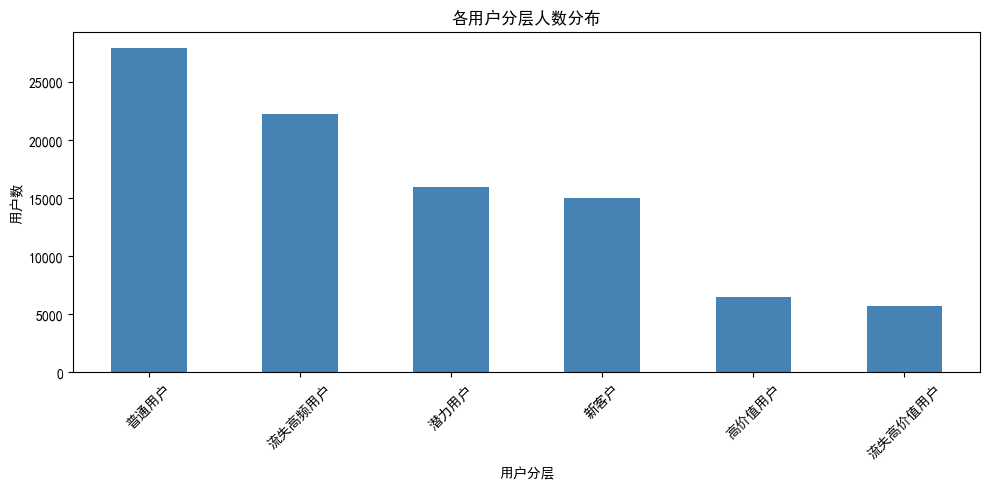

In [13]:
segment_stats = rfm.groupby('用户分层').agg(
    用户数=('customer_unique_id','count'),
    平均R=('R_score','mean'),
    平均F=('F_score','mean'),
    平均M=('M_score','mean'),
    平均消费额=('Monetary','mean')
).round(2)

segment_stats['用户占比'] = (segment_stats['用户数'] / 
                            segment_stats['用户数'].sum() * 100).round(1)
segment_stats = segment_stats.sort_values('用户数', ascending=False)
print(segment_stats)

plt.figure(figsize=(10, 5))
segment_stats['用户数'].plot(kind='bar', color='steelblue')
plt.title('各用户分层人数分布')
plt.xlabel('用户分层')
plt.ylabel('用户数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 各层用户消费行为对比

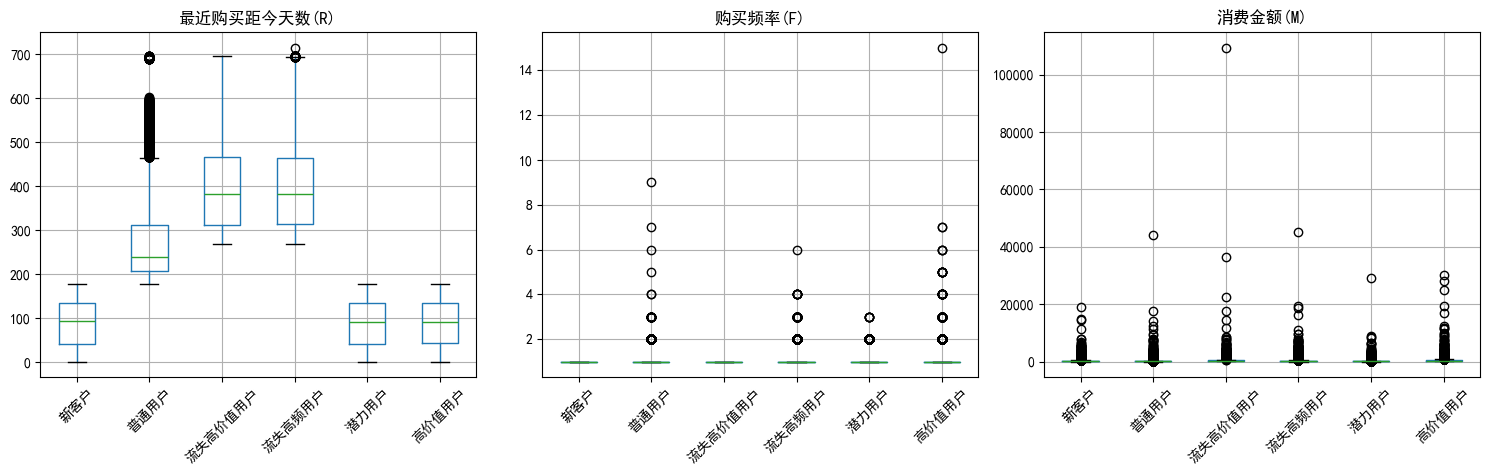

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes, 
                           ['Recency','Frequency','Monetary'],
                           ['最近购买距今天数(R)','购买频率(F)','消费金额(M)']):
    rfm.boxplot(column=col, by='用户分层', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

## 核心结论

In [16]:
print("=== RFM用户分层核心结论 ===\n")

for seg, row in segment_stats.iterrows():
    print(f"【{seg}】{row['用户数']}人（占比{row['用户占比']}%）"
          f" | 平均消费额：{row['平均消费额']:.0f}巴西雷亚尔")

print("\n=== 运营建议 ===")
print("1. 重要价值用户：维持现有服务，推送会员权益，防止流失")
print("2. 重要发展用户：提高购买频率，推送关联品类和优惠券")  
print("3. 重要挽回用户：已有消费能力但沉寂，推送召回活动")
print("4. 流失用户：占比最大，成本高，仅对高M值用户做挽回")

=== RFM用户分层核心结论 ===

【普通用户】27933.0人（占比29.9%） | 平均消费额：157巴西雷亚尔
【流失高频用户】22219.0人（占比23.8%） | 平均消费额：212巴西雷亚尔
【潜力用户】15989.0人（占比17.1%） | 平均消费额：138巴西雷亚尔
【新客户】14984.0人（占比16.1%） | 平均消费额：204巴西雷亚尔
【高价值用户】6460.0人（占比6.9%） | 平均消费额：442巴西雷亚尔
【流失高价值用户】5760.0人（占比6.2%） | 平均消费额：439巴西雷亚尔

=== 运营建议 ===
1. 重要价值用户：维持现有服务，推送会员权益，防止流失
2. 重要发展用户：提高购买频率，推送关联品类和优惠券
3. 重要挽回用户：已有消费能力但沉寂，推送召回活动
4. 流失用户：占比最大，成本高，仅对高M值用户做挽回
